In [28]:
import uproot as up
import awkward as ak
import matplotlib.pyplot as plt
import vector as vec
import numpy as np
import pandas as pd
import os
from pathlib import Path
from scipy import stats as st

common_path = "/home/usuario/Madgraph/projects/"

Delphes = "HL-LHC"
Energy_label = "14TeV"
Total_events = "100k"

data_to_analyse = f"{Delphes}_{Energy_label}_{Total_events}"

signal = up.open(common_path + f"gg_hh-LQs/signal/Events/{data_to_analyse}_signal/tag_1_delphes_events.root")
sm = up.open(common_path + f"gg_hh-sm/Events/{data_to_analyse}_SM/tag_1_delphes_events.root")
bg = up.open(common_path + f"gg_tth_hdecaylep/Events/{data_to_analyse}_bg_hlep/tag_2_delphes_events.root")

signal_tree = signal["Delphes"]
sm_tree = sm["Delphes"]
bg_tree = bg["Delphes"]

folder_path = f'/home/usuario/VSCode/diHiggs-Project/RecAnalysis/{data_to_analyse}'

os.makedirs(folder_path, exist_ok=True)

vec.register_awkward()

In [46]:
# Utilitary functions

def parse_events(s):
    s = s.strip().lower()
    mult = {"k": 1_000, "M": 1_000_000}
    if s[-1] in mult:
        return int(float(s[:-1]) * mult[s[-1]])
    return int(s)

def calculo_rangos(lim_inf, lim_sup, data):

    if type(data) == list:

        total_events = sum(len(data_i) for data_i in data)

        debajo = sum(np.sum(data_i < lim_inf) for data_i in data)

        dentro = sum(
            np.sum((data_i >= lim_inf) & (data_i <= lim_sup))
            for data_i in data
        )

        encima = sum(np.sum(data_i > lim_sup) for data_i in data)

        p_debajo = 100 * debajo / total_events
        p_dentro = 100 * dentro / total_events
        p_encima = 100 * encima / total_events

        return lim_inf, lim_sup, p_debajo, p_dentro, p_encima

    else:

        return print("Error: data debe ser una lista de arrays de datos.")

def vectors_buildup(data):
    jets = ak.zip({
        "pt": data["Jet.PT"],
        "eta": data["Jet.Eta"],
        "phi": data["Jet.Phi"],
        "mass": data["Jet.Mass"],
        'TauTag': data["Jet.TauTag"],
        'BTag': data["Jet.BTag"],
    }, with_name="Momentum4D")

    tracks = ak.zip({
        "pt": data["Track.PT"],
        "eta": data["Track.Eta"],
        "phi": data["Track.Phi"],
        "mass": data["Track.Mass"],
        "d0":  data["Track.D0"],  
        "dz":  data["Track.DZ"]
    }, with_name="Momentum4D")

    return jets, tracks

# Selection Functions

def MET_trigger(data, MET_lowerbond):

    MET_mask = ak.flatten(data["MissingET.MET"]) > MET_lowerbond

    return MET_mask

def cinematic_cut(vec, Pt_lowerBond, Eta_absoluteBond):
    cinematic_mask = (vec.pt > Pt_lowerBond) & (abs(vec.eta) < Eta_absoluteBond)
    return cinematic_mask

def Selected_data(data, MET_LB, PT_LB, Eta_AB):

    MET_mask = MET_trigger(data, MET_LB)

    data_selected = data[MET_mask]

    # Construyo los jets, con su cuadrivector y los BTag y tautag

    jets_select, tracks_select = vectors_buildup(data_selected)

    cinematic_mask = cinematic_cut(jets_select, PT_LB, Eta_AB)

    jets_select, tracks_select = jets_select[cinematic_mask], tracks_select[cinematic_mask]

    return jets_select, tracks_select

def Taus_and_bjets(jets):
    taus = jets[(jets['TauTag'] == 1) & (jets['BTag'] == 0)]
    bjets = jets[(jets['TauTag'] == 0) & (jets['BTag'] == 1)]

    N_events = len(ak.sum(jets, axis=1))
    N_taus = ak.num(taus, axis=1)
    N_bjets = ak.num(bjets, axis=1)

    return taus, bjets, N_events, N_taus, N_bjets

def kinematic_hierarchical_order(taus, bjets):
    mask  = (ak.num(taus) >= 2) & (ak.num(bjets) >= 2)
    taus_cut, bjets_cut = taus[mask], bjets[mask]
    tau1, tau2 = taus_cut[:,0], taus_cut[:,1]
    b1, b2     = bjets_cut[:,0], bjets_cut[:,1]
    return tau1, tau2, b1, b2, taus_cut, bjets_cut

def PT_and_IM_of_products(tau1, tau2, b1, b2):
    M_tautau = (tau1+tau2).mass
    M_bb     = (b1+b2).mass
    M_hh     = (tau1+tau2+b1+b2).mass

    PT_tautau = (tau1+tau2).pt
    PT_bb     = (b1+b2).pt
    PT_hh     = (tau1+tau2+b1+b2).pt

    tuple_tautau = (M_tautau, PT_tautau)
    tuple_bb = (M_bb, PT_bb)
    tuple_hh = (M_hh, PT_hh)

    return tuple_tautau, tuple_bb, tuple_hh


In [30]:
extracted_keys = ["Jet.PT","Jet.Eta", "Jet.Phi", "Jet.Mass", "Jet.BTag","Jet.TauTag", "MissingET.MET",
            'Track.PT', 'Track.Eta', 'Track.Phi', 'Track.Mass', 'Track.PID', 'Track.DZ', 'Track.D0', 'Track.Charge']

data_sl = signal_tree.arrays(extracted_keys)
data_bg = bg_tree.arrays(extracted_keys)
data_sm = sm_tree.arrays(extracted_keys)

N_events_sl = len(data_sl)
N_events_bg = len(data_bg)
N_events_sm = len(data_sm)
N_events_text = parse_events(Total_events)

def check_events(expected, **muestras):
    distintos = {k: v for k, v in muestras.items() if v != expected}
    if distintos:
        raise ValueError(f"Se esperaban {expected} eventos; difieren: {distintos}")
    return print(f'All dataset contain: {expected} events')

N_events_text = parse_events(Total_events)

check_events(N_events_text,
             signal=len(data_sl),
             background=len(data_bg),
             sm=len(data_sm))

All dataset contain: 100000 events


# MET and Kinematic cuts

[15.984122]


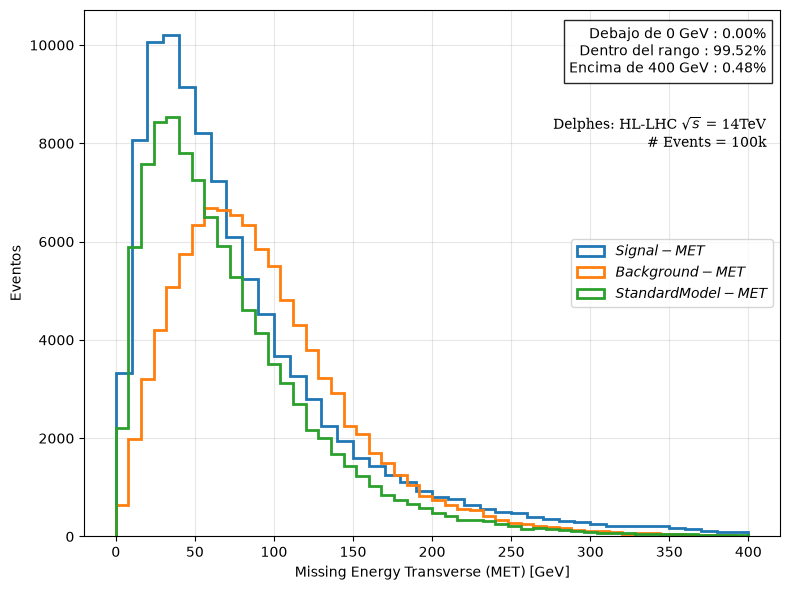

In [31]:
# Distribucion de MET, solo con corte de Cinemática

MET_sl = data_sl["MissingET.MET"]
MET_sm = data_sm["MissingET.MET"]
MET_bg = data_bg["MissingET.MET"]

print(st.mode(MET_sl)[0])

data = [MET_sl, MET_sm, MET_bg]

lim_inf, lim_sup, p_debajo, p_dentro, p_encima = calculo_rangos(0,400, data)

Data_text_ID_precut = (fr"Delphes: {Delphes} " r"$\sqrt{s}$" f" = {Energy_label}" "\n"
                fr"# Events = {Total_events}")

plt.figure(figsize=(8,6))

texto = (f"Debajo de {lim_inf} GeV : {p_debajo:.2f}%\n"f"Dentro del rango : {p_dentro:.2f}%\n"f"Encima de {lim_sup} GeV : {p_encima:.2f}%")
plt.text(0.98, 0.97,texto,transform=plt.gca().transAxes,ha="right",va="top",bbox=dict(facecolor="white", alpha=0.85))

plt.text(0.98, 0.8, Data_text_ID_precut, transform=plt.gca().transAxes,
        ha="right", va="top", fontsize=10, family="DejaVu Serif")

plt.hist(MET_sl, bins=40, density=False, range=(lim_inf, lim_sup), histtype="step", linewidth=2, label=r"$Signal - MET$")
plt.hist(MET_bg, bins=50, density=False, range=(lim_inf, lim_sup), histtype="step", linewidth=2, label=r"$Background - MET$")
plt.hist(MET_sm, bins=50, density=False, range=(lim_inf, lim_sup), histtype="step", linewidth=2, label=r"$Standard Model - MET$")
plt.xlabel(r"Missing Energy Transverse (MET) [GeV]")
plt.ylabel("Eventos")
plt.legend(loc = 'center right')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{folder_path}/MET_distribution.png", dpi=300)
plt.show()

In [32]:
# Parámetros a definir

# [0, 20, 50, 70, 100, 150]

MET_LowerBond = 0     # GeV
PT_LowerBond = 20       # GeV
Eta_AbsoluteBond = 2.5

selected_data_folder_path = f"{data_to_analyse}/MET{MET_LowerBond}_PT{PT_LowerBond}_Eta{Eta_AbsoluteBond}"

Data_text_ID = (fr"Delphes: {Delphes} " r"$\sqrt{s}$" f" = {Energy_label}" "\n"
                fr"MET > {MET_LowerBond} GeV" "\n"
                fr"$p_T$ > {PT_LowerBond} GeV" "\n"
                rf"$|\eta| < {Eta_AbsoluteBond}$")

os.makedirs(selected_data_folder_path, exist_ok=True)

jets_sl, tracks_sl = Selected_data(data_sl, MET_LowerBond, PT_LowerBond, Eta_AbsoluteBond)
jets_bg, tracks_bg = Selected_data(data_bg, MET_LowerBond, PT_LowerBond, Eta_AbsoluteBond)
jets_sm, tracks_sm = Selected_data(data_sm, MET_LowerBond, PT_LowerBond, Eta_AbsoluteBond)

# Tracks Analysis

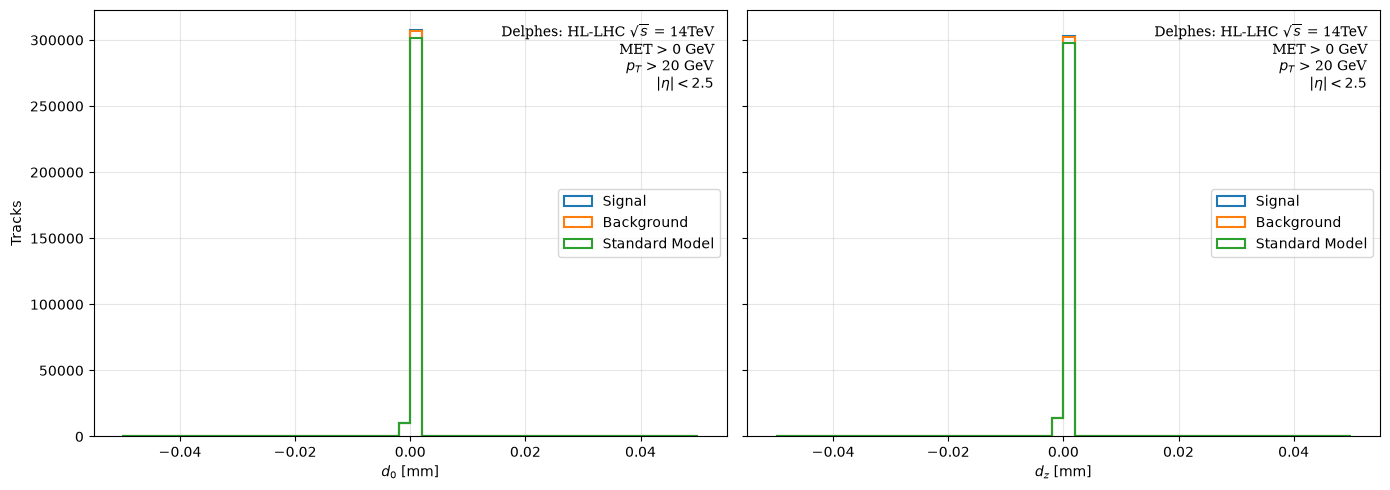

In [33]:
d0_sl = ak.to_numpy(ak.flatten(tracks_sl.d0))
dz_sl = ak.to_numpy(ak.flatten(tracks_sl.dz))

d0_bg = ak.to_numpy(ak.flatten(tracks_bg.d0))
dz_bg = ak.to_numpy(ak.flatten(tracks_bg.dz))

d0_sm = ak.to_numpy(ak.flatten(tracks_sm.d0))
dz_sm = ak.to_numpy(ak.flatten(tracks_sm.dz))

fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=True)

axes[0].hist(d0_sl, bins=50, range=(-0.05,0.05), histtype="step", linewidth=1.5, label = 'Signal')
axes[0].hist(d0_bg, bins=50, range=(-0.05,0.05), histtype="step", linewidth=1.5, label = 'Background')
axes[0].hist(d0_sm, bins=50, range=(-0.05,0.05), histtype="step", linewidth=1.5, label = 'Standard Model')
axes[0].set_xlabel(r"$d_0$ [mm]")
axes[0].set_ylabel("Tracks")


axes[1].hist(dz_sl, bins=50, range=(-0.05,0.05), histtype="step", linewidth=1.5, label = 'Signal')
axes[1].hist(dz_bg, bins=50, range=(-0.05,0.05), histtype="step", linewidth=1.5, label = 'Background')
axes[1].hist(dz_sm, bins=50, range=(-0.05,0.05), histtype="step", linewidth=1.5, label = 'Standard Model')
axes[1].set_xlabel(r"$d_z$ [mm]")

for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend(loc = 'center right')
    ax.text(0.98, 0.97, Data_text_ID, transform=ax.transAxes,
        ha="right", va="top", fontsize=10, family="DejaVu Serif")

plt.tight_layout()
plt.savefig(f"{selected_data_folder_path}/Vertex_displacement.png", dpi=300)
plt.show()

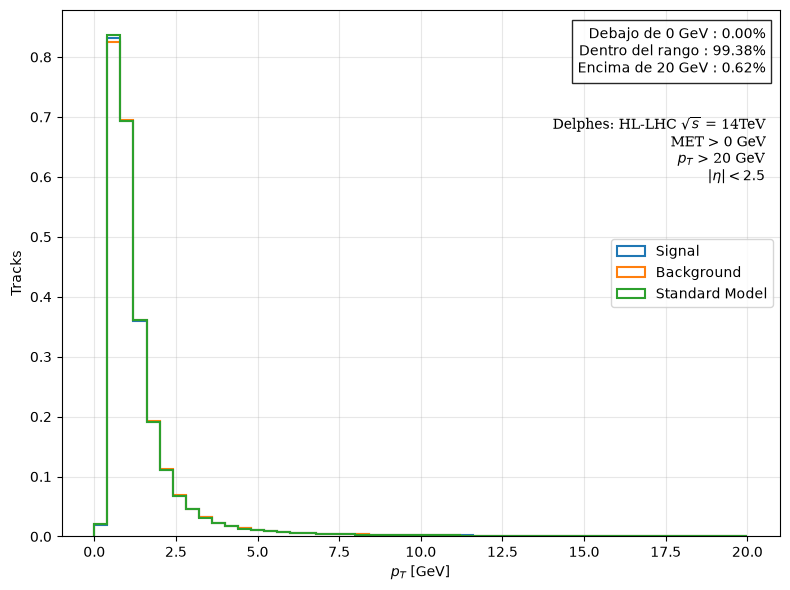

In [34]:
pt_tracks_sl = ak.to_numpy(ak.flatten(tracks_sl.pt))
pt_tracks_bg = ak.to_numpy(ak.flatten(tracks_bg.pt))
pt_tracks_sm = ak.to_numpy(ak.flatten(tracks_sm.pt))

pt_tracks_data = [pt_tracks_sl, pt_tracks_bg, pt_tracks_sm]

lim_inf, lim_sup, p_debajo, p_dentro, p_encima = calculo_rangos(0,20, pt_tracks_data)

plt.figure(figsize=(8,6))

plt.hist(pt_tracks_sl, bins=50, range=(lim_inf, lim_sup), density = True, histtype="step", linewidth=1.5, label = 'Signal')
plt.hist(pt_tracks_bg, bins=50, range=(lim_inf, lim_sup), density = True, histtype="step", linewidth=1.5, label = 'Background')
plt.hist(pt_tracks_sm, bins=50, range=(lim_inf, lim_sup), density = True, histtype="step", linewidth=1.5, label = 'Standard Model')
plt.xlabel(r"$p_T$ [GeV]")
plt.ylabel("Tracks")

plt.grid(alpha=0.3)
plt.legend(loc = 'center right')

texto = (f"Debajo de {lim_inf} GeV : {p_debajo:.2f}%\n"f"Dentro del rango : {p_dentro:.2f}%\n"f"Encima de {lim_sup} GeV : {p_encima:.2f}%")
plt.text(0.98, 0.97,texto,transform=plt.gca().transAxes,ha="right",va="top",bbox=dict(facecolor="white", alpha=0.85))

plt.text(0.98, 0.80, Data_text_ID, transform=plt.gca().transAxes,
        ha="right", va="top", fontsize=10, family="DejaVu Serif")

plt.tight_layout()
plt.savefig(f"{selected_data_folder_path}/Tracks_PT_distribution.png", dpi=300)
plt.show()

# Jets Analysis

In [51]:
# Ahora separo en taus y bs

taus_sl, bjets_sl, N_events_sl, N_taus_sl, N_bjets_sl = Taus_and_bjets(jets_sl)
taus_bg, bjets_bg, N_events_bg, N_taus_bg, N_bjets_bg = Taus_and_bjets(jets_bg)
taus_sm, bjets_sm, N_events_sm, N_taus_sm, N_bjets_sm = Taus_and_bjets(jets_sm)

# Selección de eventos con 2 taus y 2 b-jets

tau1_sl, tau2_sl, b1_sl, b2_sl, taus_cut_sl, bjets_cut_sl = kinematic_hierarchical_order(taus_sl, bjets_sl)
tau1_bg, tau2_bg, b1_bg, b2_bg, taus_cut_bg, bjets_cut_bg = kinematic_hierarchical_order(taus_bg, bjets_bg)
tau1_sm, tau2_sm, b1_sm, b2_sm, taus_cut_sm, bjets_cut_sm = kinematic_hierarchical_order(taus_sm, bjets_sm)

# Distribucion de masas invariante y de PT de los pares tau-tau y b-b

LQ_tuple_tautau, LQ_tuple_bb, LQ_tuple_hh = PT_and_IM_of_products(tau1_sl, tau2_sl, b1_sl, b2_sl)
BG_tuple_tautau, BG_tuple_bb, BG_tuple_hh = PT_and_IM_of_products(tau1_bg, tau2_bg, b1_bg, b2_bg)
SM_tuple_tautau, SM_tuple_bb, SM_tuple_hh = PT_and_IM_of_products(tau1_sm, tau2_sm, b1_sm, b2_sm)

LQ_m_tautau, LQ_m_bb, LQ_m_hh = LQ_tuple_tautau[0], LQ_tuple_bb[0], LQ_tuple_hh[0]
BG_m_tautau, BG_m_bb, BG_m_hh = BG_tuple_tautau[0], BG_tuple_bb[0], BG_tuple_hh[0]
SM_m_tautau, SM_m_bb, SM_m_hh = SM_tuple_tautau[0], SM_tuple_bb[0], SM_tuple_hh[0]

LQ_pt_tautau, LQ_pt_bb, LQ_pt_hh = LQ_tuple_tautau[1], LQ_tuple_bb[1], LQ_tuple_hh[1]
BG_pt_tautau, BG_pt_bb, BG_pt_hh = BG_tuple_tautau[1], BG_tuple_bb[1], BG_tuple_hh[1]
SM_pt_tautau, SM_pt_bb, SM_pt_hh = SM_tuple_tautau[1], SM_tuple_bb[1], SM_tuple_hh[1]

# Distribución de DeltaR entre los pares tau-tau y b-b

DeltaR_tautau = tau1_sl.deltaR(tau2_sl)
DeltaR_bb = b1_sl.deltaR(b2_sl)

DeltaR_tautau_SM = tau1_sm.deltaR(tau2_sm)
DeltaR_bb_SM = b1_sm.deltaR(b2_sm)

DeltaR_tautau_BG = tau1_bg.deltaR(tau2_bg)
DeltaR_bb_BG = b1_bg.deltaR(b2_bg)

In [36]:
# Resultados de los cortes

etiquetas = ["Señal", "Fondo", "Modelo Estándar"]
data_all  = [data_sl, data_bg, data_sm]
jets_all  = [jets_sl, jets_bg, jets_sm]
taus_all  = [taus_cut_sl, taus_cut_bg, taus_cut_sm]

def doubletag_events(jets):
    dt = (jets['TauTag'] == 1) & (jets['BTag'] == 1)
    n_dt = int(ak.sum(ak.num(jets[dt], axis=1) > 0))
    n_ev = len(jets)
    return n_dt, 100 * n_dt / n_ev if n_ev else 0.0


lineas = [Data_text_ID, ""]
lineas.append(f"{'Muestra':<18} {'Generados':>10} {'Pasan MET':>10} {'Acept. MET':>11} "
              f"{'Sel. 2t+2b':>11} {'Acept.':>8} {'Acept. tot.':>12} "
              f"{'Ev. doble tag':>14} {'% doble':>8}")
lineas.append("-" * 112)

for nombre, data, jets, taus_cut in zip(etiquetas, data_all, jets_all, taus_all):
    n_gen = len(data)
    n_met = len(jets)
    n_sel = len(taus_cut)

    acc_met = 100 * n_met / n_gen if n_gen else 0.0
    acc_sel = 100 * n_sel / n_met if n_met else 0.0
    acc_tot = 100 * n_sel / n_gen if n_gen else 0.0

    n_dt, pct_dt = doubletag_events(jets)

    lineas.append(f"{nombre:<18} {n_gen:>10} {n_met:>10} {acc_met:>10.2f}% "
                  f"{n_sel:>11} {acc_sel:>7.2f}% {acc_tot:>11.2f}% "
                  f"{n_dt:>14} {pct_dt:>7.2f}%")

texto = "\n".join(lineas)
print(texto)
_ = (Path(selected_data_folder_path) / "cutflow.txt").write_text(texto + "\n")

Delphes: HL-LHC $\sqrt{s}$ = 14TeV
MET > 0 GeV
$p_T$ > 20 GeV
$|\eta| < 2.5$

Muestra             Generados  Pasan MET  Acept. MET  Sel. 2t+2b   Acept.  Acept. tot.  Ev. doble tag  % doble
----------------------------------------------------------------------------------------------------------------
Señal                  100000     100000     100.00%        2491    2.49%        2.49%           6848    6.85%
Fondo                  100000     100000     100.00%        1976    1.98%        1.98%           9998   10.00%
Modelo Estándar        100000     100000     100.00%        2252    2.25%        2.25%           6763    6.76%


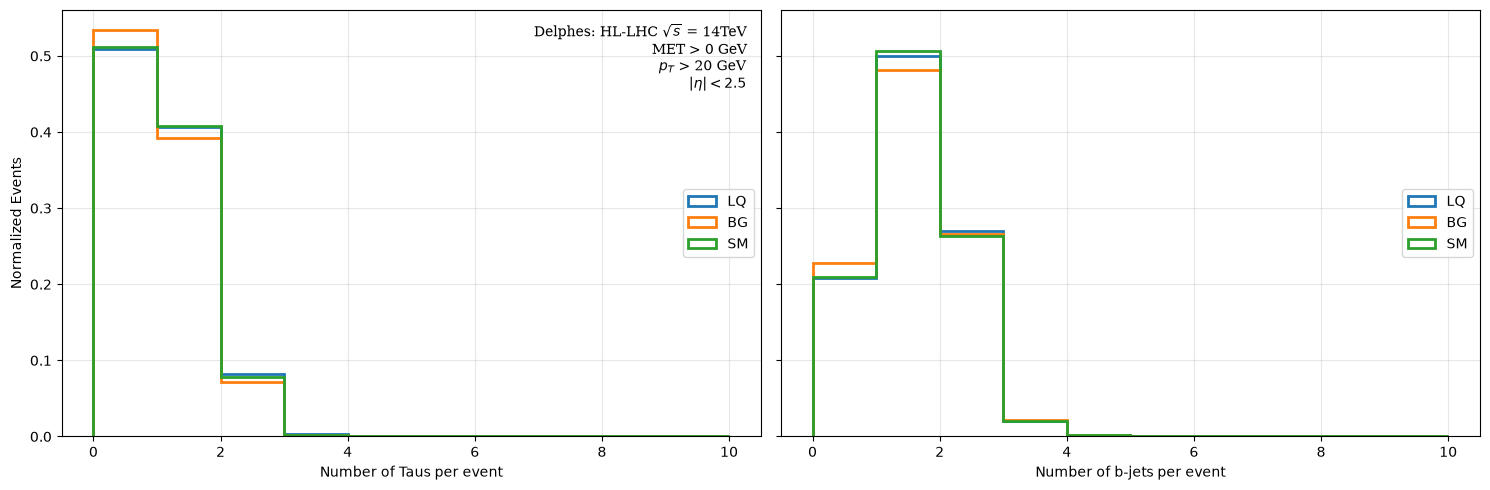

In [37]:
bines = np.linspace(0,10, 11)

fig, axes = plt.subplots(1, 2, figsize=(15,5), sharey=True)

axes[0].text(0.98, 0.97, Data_text_ID, transform=axes[0].transAxes,
        ha="right", va="top", fontsize=10, family="DejaVu Serif")

# --- Subplot izquierdo: señal ---
axes[0].hist(N_taus_sl, bins=bines, density=True, histtype="step", linewidth=2, label=r"LQ")
axes[0].hist(N_taus_bg, bins=bines, density=True, histtype="step", linewidth=2, label=r"BG")
axes[0].hist(N_taus_sm, bins=bines, density=True, histtype="step", linewidth=2, label=r"SM")
axes[0].set_xlabel(r"Number of Taus per event")
axes[0].set_ylabel("Normalized Events")
axes[0].legend(loc = "center right")
axes[0].grid(alpha=0.3)

axes[1].hist(N_bjets_sl, bins=bines, density=True, histtype="step", linewidth=2, label=r"LQ")
axes[1].hist(N_bjets_bg, bins=bines, density=True, histtype="step", linewidth=2, label=r"BG")
axes[1].hist(N_bjets_sm, bins=bines, density=True, histtype="step", linewidth=2, label=r"SM")
axes[1].set_xlabel(r"Number of b-jets per event")
axes[1].legend(loc = "center right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{selected_data_folder_path}/Higgs_pT_distribution.png", dpi=300)
plt.show()

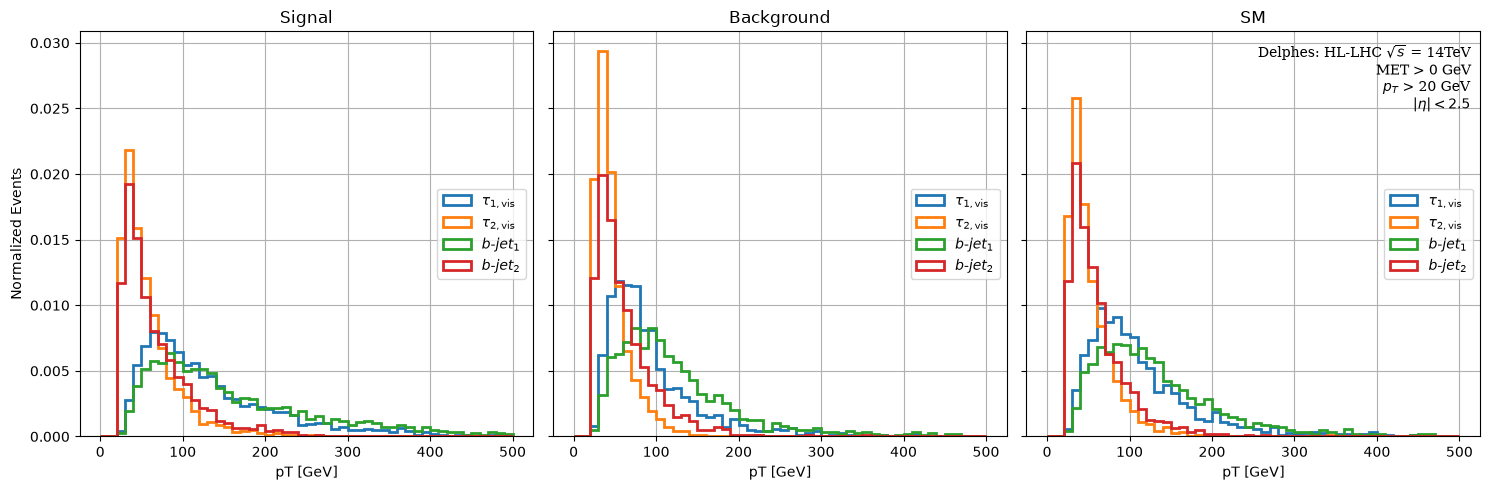

In [38]:
sets = [("Signal", tau1_sl, tau2_sl, b1_sl, b2_sl),
        ("Background", tau1_bg, tau2_bg, b1_bg, b2_bg),
        ("SM", tau1_sm, tau2_sm, b1_sm, b2_sm)]



labels = [r"$\tau_{1, \text{vis}}$", r"$\tau_{2, \text{vis}}$", r"$b\text{-}jet_1$", r"$b\text{-}jet_2$"]
kw = dict(bins=50, range=(0,500), density=True, histtype="step", linewidth=2)

fig, axes = plt.subplots(1, 3, figsize=(15,5), sharey=True)

axes[2].text(0.98, 0.97, Data_text_ID, transform=axes[2].transAxes,
        ha="right", va="top", fontsize=10, family="DejaVu Serif")

axes[0].hist(ak.to_numpy(tau1_sl.pt), label=labels[0], **kw)
axes[0].hist(ak.to_numpy(tau2_sl.pt), label=labels[1], **kw)
axes[0].hist(ak.to_numpy(b1_sl.pt), label=labels[2], **kw)
axes[0].hist(ak.to_numpy(b2_sl.pt), label=labels[3], **kw)
axes[0].set_title("Signal")
axes[0].set_ylabel("Normalized Events")
axes[0].set_xlabel("pT [GeV]")
axes[0].legend(loc = 'center right')

axes[1].hist(ak.to_numpy(tau1_bg.pt), label=labels[0], **kw)
axes[1].hist(ak.to_numpy(tau2_bg.pt), label=labels[1], **kw)
axes[1].hist(ak.to_numpy(b1_bg.pt), label=labels[2], **kw)
axes[1].hist(ak.to_numpy(b2_bg.pt), label=labels[3], **kw)
axes[1].set_title("Background")
axes[1].set_xlabel("pT [GeV]")
axes[1].legend(loc = 'center right')

axes[2].hist(ak.to_numpy(tau1_sm.pt), label=labels[0], **kw)
axes[2].hist(ak.to_numpy(tau2_sm.pt), label=labels[1], **kw)
axes[2].hist(ak.to_numpy(b1_sm.pt), label=labels[2], **kw)
axes[2].hist(ak.to_numpy(b2_sm.pt), label=labels[3], **kw)
axes[2].set_title("SM")
axes[2].set_xlabel("pT [GeV]")
axes[2].legend(loc = 'center right')

for ax in axes:
        ax.grid()

fig.tight_layout()
fig.savefig(f"{selected_data_folder_path}/pt_distribution.png", dpi=300)
plt.show()

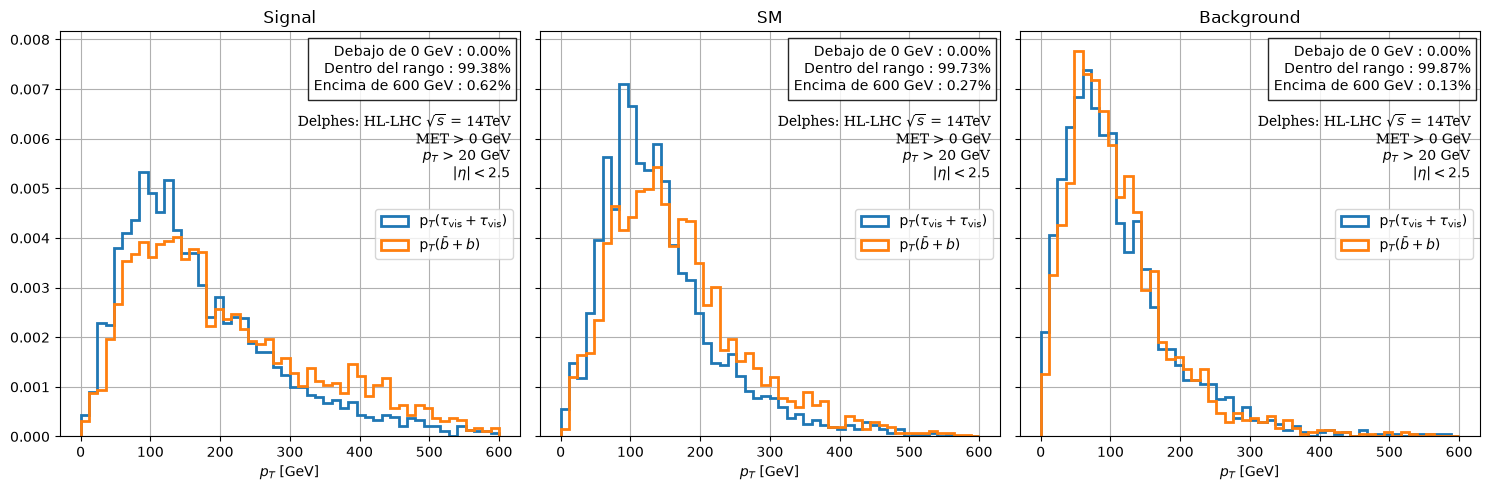

In [49]:
data_LQ = [LQ_pt_tautau, LQ_pt_bb]
data_SM = [SM_pt_tautau, SM_pt_bb]
data_BG = [BG_pt_tautau, BG_pt_bb]

lim_inf_LQ, lim_sup_LQ, p_debajo_LQ, p_dentro_LQ, p_encima_LQ = calculo_rangos(0,600, data_LQ)
lim_inf_SM, lim_sup_SM, p_debajo_SM, p_dentro_SM, p_encima_SM = calculo_rangos(0,600, data_SM)
lim_inf_BG, lim_sup_BG, p_debajo_BG, p_dentro_BG, p_encima_BG = calculo_rangos(0,600, data_BG)

fig, axes = plt.subplots(1, 3, figsize=(15,5), sharey=True)

axes[0].text(0.98, 0.80, Data_text_ID, transform=axes[0].transAxes,
        ha="right", va="top", fontsize=10, family="DejaVu Serif")

axes[1].text(0.98, 0.80, Data_text_ID, transform=axes[1].transAxes,
        ha="right", va="top", fontsize=10, family="DejaVu Serif")

axes[2].text(0.98, 0.80, Data_text_ID, transform=axes[2].transAxes,
        ha="right", va="top", fontsize=10, family="DejaVu Serif")

texto0 = (f"Debajo de {lim_inf_LQ} GeV : {p_debajo_LQ:.2f}%\n"f"Dentro del rango : {p_dentro_LQ:.2f}%\n"f"Encima de {lim_sup_LQ} GeV : {p_encima_LQ:.2f}%")
texto1 = (f"Debajo de {lim_inf_SM} GeV : {p_debajo_SM:.2f}%\n"f"Dentro del rango : {p_dentro_SM:.2f}%\n"f"Encima de {lim_sup_SM} GeV : {p_encima_SM:.2f}%")
texto2 = (f"Debajo de {lim_inf_BG} GeV : {p_debajo_BG:.2f}%\n"f"Dentro del rango : {p_dentro_BG:.2f}%\n"f"Encima de {lim_sup_BG} GeV : {p_encima_BG:.2f}%")

axes[0].text(0.98, 0.97,texto0,transform=axes[0].transAxes,ha="right",va="top",bbox=dict(facecolor="white", alpha=0.85))
axes[1].text(0.98, 0.97,texto1,transform=axes[1].transAxes,ha="right",va="top",bbox=dict(facecolor="white", alpha=0.85))
axes[2].text(0.98, 0.97,texto2,transform=axes[2].transAxes,ha="right",va="top",bbox=dict(facecolor="white", alpha=0.85))

axes[0].hist(LQ_pt_tautau, bins=50, density=True, range=(lim_inf_LQ, lim_sup_LQ), histtype="step", linewidth=2, label=r"p$_T(\tau_{\text{vis}} + \tau_{\text{vis}})$")
axes[0].hist(LQ_pt_bb, bins=50, density=True, range=(lim_inf_LQ, lim_sup_LQ), histtype="step", linewidth=2, label=r"p$_T(\bar{b} + b)$")                          
axes[0].set_title("Signal")
axes[0].set_xlabel(r"$p_T$ [GeV]")
axes[0].legend(loc = 'center right')

axes[1].hist(SM_pt_tautau, bins=50, density=True, range=(lim_inf_SM, lim_sup_SM), histtype="step", linewidth=2, label=r"p$_T(\tau_{\text{vis}} + \tau_{\text{vis}})$")
axes[1].hist(SM_pt_bb, bins=50, density=True, range=(lim_inf_SM, lim_sup_SM), histtype="step", linewidth=2, label=r"p$_T(\bar{b} + b)$")                          
axes[1].set_title("SM")
axes[1].set_xlabel(r"$p_T$ [GeV]")
axes[1].legend(loc = 'center right')

axes[2].hist(BG_pt_tautau, bins=50, density=True, range=(lim_inf_BG, lim_sup_BG), histtype="step", linewidth=2, label=r"p$_T(\tau_{\text{vis}} + \tau_{\text{vis}})$")
axes[2].hist(BG_pt_bb, bins=50, density=True, range=(lim_inf_BG, lim_sup_BG), histtype="step", linewidth=2, label=r"p$_T(\bar{b} + b)$")                          
axes[2].set_title("Background")
axes[2].set_xlabel(r"$p_T$ [GeV]")
axes[2].legend(loc = 'center right')

for ax in axes:
        ax.grid()

fig.tight_layout()
plt.savefig(f"{selected_data_folder_path}/pT_pairs.png", dpi=300)
plt.show()

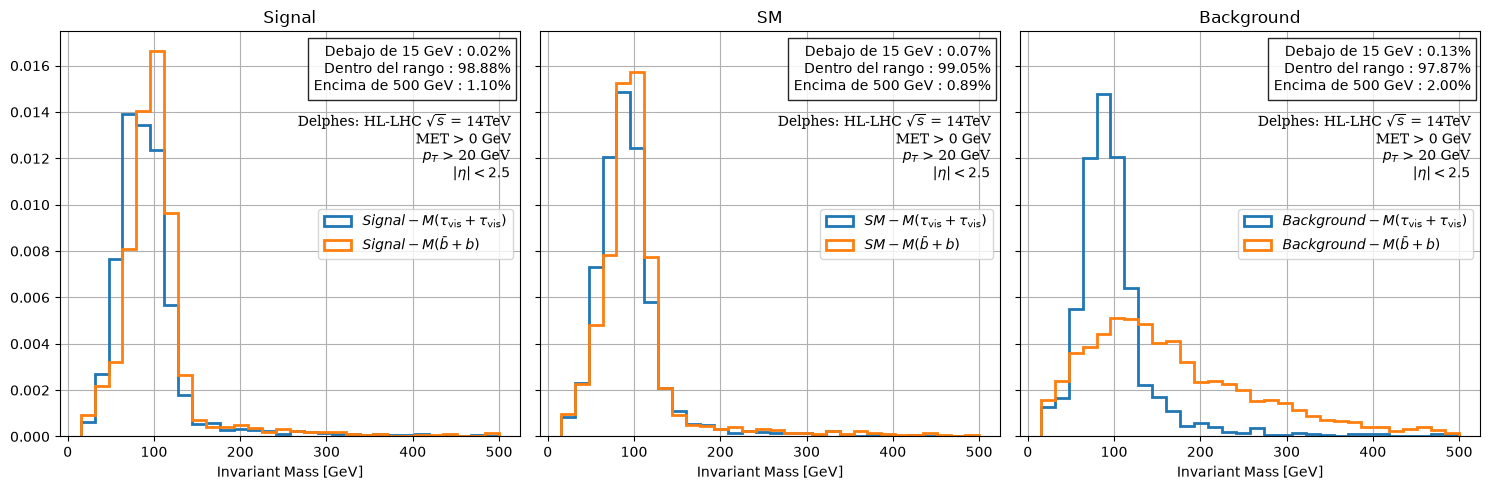

In [ ]:
data0 = [LQ_m_tautau, LQ_m_bb]
data1 = [SM_m_tautau, SM_m_bb]
data2 = [BG_m_tautau, BG_m_bb]

lim_inf_0, lim_sup_0, p_debajo_0, p_dentro_0, p_encima_0 = calculo_rangos(15,500, data0)
lim_inf_1, lim_sup_1, p_debajo_1, p_dentro_1, p_encima_1 = calculo_rangos(15,500, data1)
lim_inf_2, lim_sup_2, p_debajo_2, p_dentro_2, p_encima_2 = calculo_rangos(15,500, data2)

fig, axes = plt.subplots(1, 3, figsize=(15,5), sharey=True)

axes[0].text(0.98, 0.80, Data_text_ID, transform=axes[0].transAxes,
        ha="right", va="top", fontsize=10, family="DejaVu Serif")

axes[1].text(0.98, 0.80, Data_text_ID, transform=axes[1].transAxes,
        ha="right", va="top", fontsize=10, family="DejaVu Serif")

axes[2].text(0.98, 0.80, Data_text_ID, transform=axes[2].transAxes,
        ha="right", va="top", fontsize=10, family="DejaVu Serif")

texto0 = (f"Debajo de {lim_inf_0} GeV : {p_debajo_0:.2f}%\n"f"Dentro del rango : {p_dentro_0:.2f}%\n"f"Encima de {lim_sup_0} GeV : {p_encima_0:.2f}%")
texto1 = (f"Debajo de {lim_inf_1} GeV : {p_debajo_1:.2f}%\n"f"Dentro del rango : {p_dentro_1:.2f}%\n"f"Encima de {lim_sup_1} GeV : {p_encima_1:.2f}%")
texto2 = (f"Debajo de {lim_inf_2} GeV : {p_debajo_2:.2f}%\n"f"Dentro del rango : {p_dentro_2:.2f}%\n"f"Encima de {lim_sup_2} GeV : {p_encima_2:.2f}%")

axes[0].text(0.98, 0.97,texto0,transform=axes[0].transAxes,ha="right",va="top",bbox=dict(facecolor="white", alpha=0.85))
axes[1].text(0.98, 0.97,texto1,transform=axes[1].transAxes,ha="right",va="top",bbox=dict(facecolor="white", alpha=0.85))
axes[2].text(0.98, 0.97,texto2,transform=axes[2].transAxes,ha="right",va="top",bbox=dict(facecolor="white", alpha=0.85))

axes[0].hist(LQ_m_tautau, bins=30, density=True, range=(lim_inf_0, lim_sup_0), histtype="step", linewidth=2, label=r"$Signal - M(\tau_{\text{vis}} + \tau_{\text{vis}})$")
axes[0].hist(LQ_m_bb, bins=30, density=True, range=(lim_inf_0, lim_sup_0), histtype="step", linewidth=2, label=r"$Signal - M(\bar{b} + b)$")
axes[0].set_title("Signal")
axes[0].set_xlabel("Invariant Mass [GeV]")
axes[0].legend(loc = 'center right')

axes[1].hist(SM_m_tautau, bins=30, density=True, range=(lim_inf_1, lim_sup_1), histtype="step", linewidth=2, label=r"$SM - M(\tau_{\text{vis}} + \tau_{\text{vis}})$")
axes[1].hist(SM_m_bb, bins=30, density=True, range=(lim_inf_1, lim_sup_1), histtype="step", linewidth=2, label=r"$SM - M(\bar{b} + b)$")
axes[1].set_title("SM")
axes[1].set_xlabel("Invariant Mass [GeV]")
axes[1].legend(loc = 'center right')

axes[2].hist(BG_m_tautau, bins=30, density=True, range=(lim_inf_2, lim_sup_2), histtype="step", linewidth=2, label=r"$Background - M(\tau_{\text{vis}} + \tau_{\text{vis}})$")
axes[2].hist(BG_m_bb, bins=30, density=True, range=(lim_inf_2, lim_sup_2), histtype="step", linewidth=2, label=r"$Background - M(\bar{b} + b)$")
axes[2].set_title("Background")
axes[2].set_xlabel("Invariant Mass [GeV]")
axes[2].legend(loc = 'center right')

for ax in axes:
        ax.grid()

fig.tight_layout()
plt.savefig(f"{selected_data_folder_path}/MassControl.png", dpi=300)
plt.show()

In [ ]:
data = [LQ_m_hh, SM_m_hh, BG_m_hh]

lim_inf, lim_sup, p_debajo, p_dentro, p_encima = calculo_rangos(130,1500, data)

plt.figure(figsize=(8,6))

plt.text(0.98, 0.80, Data_text_ID, transform=plt.gca().transAxes,
        ha="right", va="top", fontsize=10, family="DejaVu Serif")

texto = (f"Debajo de {lim_inf} GeV : {p_debajo:.2f}%\n"f"Dentro del rango : {p_dentro:.2f}%\n"f"Encima de {lim_sup} GeV : {p_encima:.2f}%")
plt.text(0.98, 0.97,texto,transform=plt.gca().transAxes,ha="right",va="top",bbox=dict(facecolor="white", alpha=0.85))

plt.hist(LQ_m_hh, bins=40, density=True, range=(lim_inf, lim_sup), histtype="step", linewidth=2, label=r"$Signal - M(\tau_{\text{vis}} \tau_{\text{vis}} b b)$")
plt.hist(SM_m_hh, bins=40, density=True, range=(lim_inf, lim_sup), histtype="step", linewidth=2, label=r"$Standard Model - M(\tau_{\text{vis}} \tau_{\text{vis}} b b)$")
plt.hist(BG_m_hh, bins=40, density=True, range=(lim_inf, lim_sup), histtype="step", linewidth=2, label=r"$Background - M(\tau_{\text{vis}} \tau_{\text{vis}} b b)$")
plt.xlabel(r"$M$ [GeV]")
plt.ylabel("Eventos")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{selected_data_folder_path}/InvariantMass_distribution.png", dpi=300)
plt.show()

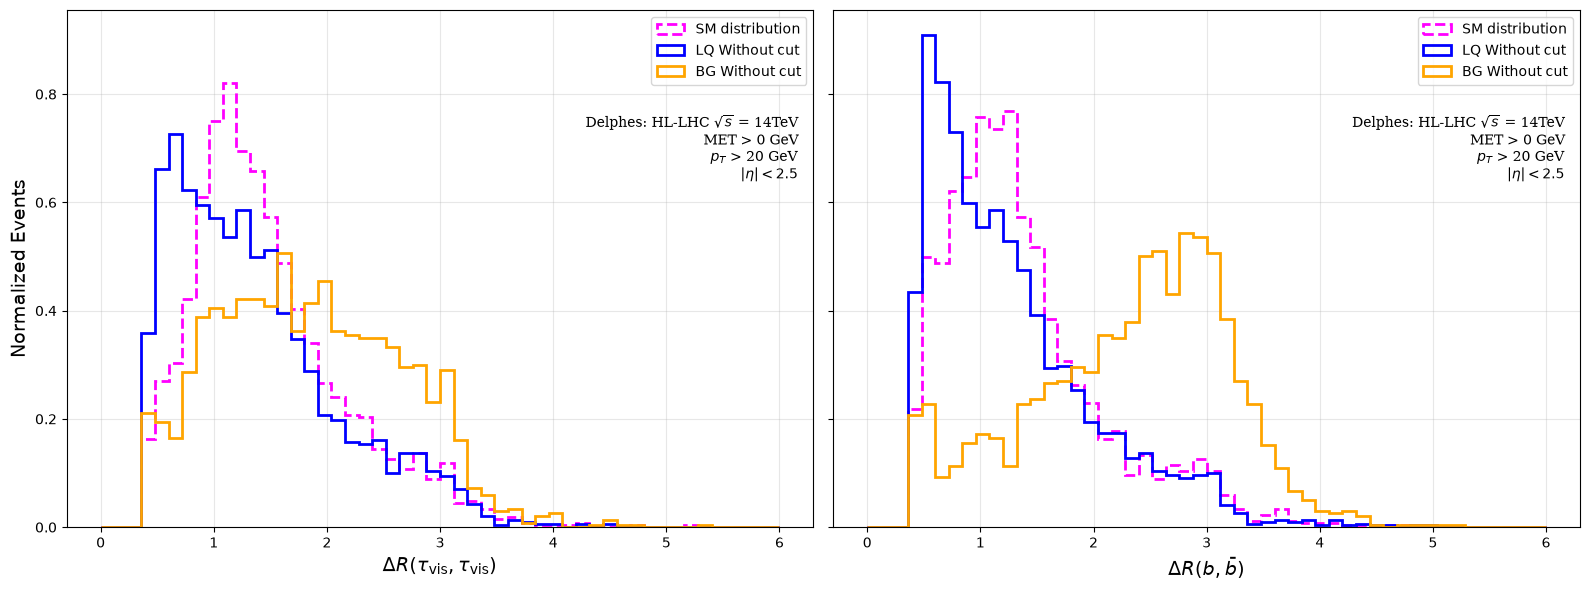

In [44]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6), sharey=True)

ax1.text(0.98, 0.80, Data_text_ID, transform=ax1.transAxes,
        ha="right", va="top", fontsize=10, family="DejaVu Serif")

ax2.text(0.98, 0.80, Data_text_ID, transform=ax2.transAxes,
        ha="right", va="top", fontsize=10, family="DejaVu Serif")

# ==========================================================
# Primer gráfico
# ==========================================================

ax1.hist(DeltaR_tautau_SM,bins=50,range=(0,6),histtype="step", density = True,color="magenta",linestyle="--",linewidth=2,label="SM distribution")

ax1.hist(DeltaR_tautau,bins=50,range=(0,6),histtype="step", density = True,color="blue",linewidth=2,label="LQ Without cut")

ax1.hist(DeltaR_tautau_BG,bins=50,range=(0,6),histtype="step", density = True,color="orange",linewidth=2,label="BG Without cut")

ax1.set_xlabel(r"$\Delta R(\tau_{\text{vis}},\tau_{\text{vis}})$", fontsize=14)
ax1.set_ylabel("Normalized Events", fontsize=14)
ax1.grid(alpha=0.3)
ax1.legend(fontsize=10)

# ==========================================================
# Segundo gráfico
# ==========================================================

ax2.hist(DeltaR_bb_SM,bins=50,range=(0,6),histtype="step", density = True,color="magenta",linestyle="--",linewidth=2,label="SM distribution")

ax2.hist(DeltaR_bb,bins=50,range=(0,6),histtype="step", density = True,color="blue",linewidth=2,label="LQ Without cut")

ax2.hist(DeltaR_bb_BG,bins=50,range=(0,6),histtype="step", density = True,color="orange",linewidth=2,label="BG Without cut")

ax2.set_xlabel(r"$\Delta R(b,\bar{b})$", fontsize=14)
ax2.grid(alpha=0.3)
ax2.legend(fontsize=10)

# ==========================================================
# Ajustes finales
# ==========================================================

plt.tight_layout()

plt.savefig(f"{selected_data_folder_path}/DeltaR_distribution.png", dpi=300)

plt.show()

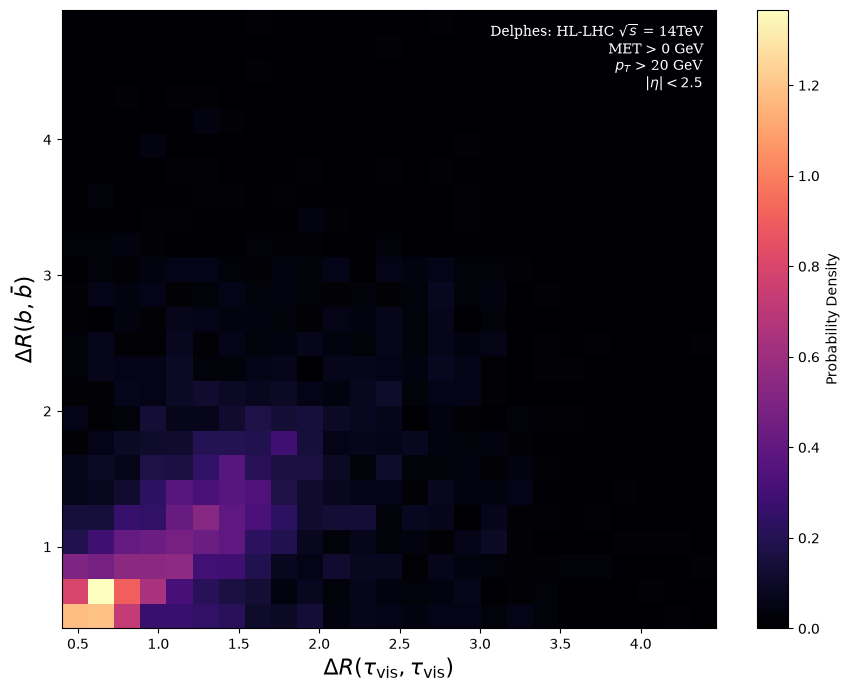

In [45]:
# Grafico 2D de DeltaR(tau tau) vs DeltaR(b b)

plt.figure(figsize=(9,7))

plt.hist2d(ak.to_numpy(DeltaR_tautau), ak.to_numpy(DeltaR_bb), bins=25, cmap="magma", density=True)
# plt.hist2d(DeltaR_tautau_SM, DeltaR_bb_SM, bins=50, cmap="viridis", density=True)

plt.colorbar(label="Probability Density")
plt.xlabel(r"$\Delta R(\tau_{\text{vis}},\tau_{\text{vis}})$", fontsize=16)
plt.ylabel(r"$\Delta R(b,\bar{b})$", fontsize=16)

plt.text(0.98, 0.98, Data_text_ID, transform=plt.gca().transAxes,
        ha="right", va="top", fontsize=10, family="DejaVu Serif", color="white")

plt.tight_layout()
plt.savefig(f"{selected_data_folder_path}/2D-DeltaR_distribution.png", dpi=300)
plt.show()